# 02 — ASR quality (WER) and prosody features

Notebook 01 left two loose threads: Whisper erased **100% of filled pauses**, and word count
alone carried most of the predictive signal (QWK 0.58 of 0.62). This notebook pulls on both:

1. **How accurate is `whisper-small`** against the corpus's gold (manual, disfluent-form) transcripts — WER?
2. **Does ASR error vary with proficiency?** If Whisper is worse for weaker speakers, ASR errors propagate unevenly into features — a fairness concern, not just a noise floor.
3. **Quantify the disfluency erasure** properly, against word-level gold annotations (`hesitation` tags, `disfluency` marks) — and check whether the erased signal would even have been predictive.
4. **Prosody features from raw audio** (pitch, intensity via Praat/parselmouth) — ASR-*independent* signal: do they add anything over the fluency set?
5. **Replace TTR with MTLD** — notebook 01 showed the textbook length-sensitivity artefact (TTR correlated *negatively* with proficiency).

*Licence note: all outputs are aggregates — no per-speaker rows, no transcript text.*

In [1]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd

# Resolve the project root whether the notebook runs from notebooks/ or the repo root
ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
assert (ROOT / "data" / "sandi-corpus-2025").exists(), f"corpus not found under {ROOT}"

CORPUS = ROOT / "data" / "sandi-corpus-2025"
REF = CORPUS / "reference-materials"
DERIVED = ROOT / "data" / "derived"          # gitignored cache (transcripts, prosody)

PART = "P3"
SEED = 42
PAUSE_GAP = 0.3              # silence >= 0.3s between words counts as a pause
LONG_PAUSE = 1.0             # silence >= 1.0s counts as a long pause

print(f"project root: {ROOT.name}/  |  part: {PART}")

project root: speech_scoring_evaluation_lab/  |  part: P3


## 1. Reload the notebook-01 sample

Notebook 01's stratified sampling is reproduced *exactly* (same seed, same code) rather than
just filtering to the cached utterances — row order determines the 5-fold CV split, so this
makes every model number directly comparable with notebook 01.

In [2]:
cache = json.load(open(DERIVED / f"transcripts_{PART}_small.json"))

scores = pd.read_csv(REF / "sla-marks" / f"dev-sla-{PART}.tsv", sep="\t", names=["speaker", "score"])
flist = pd.read_csv(REF / "flists.flac" / f"dev-sla-{PART}.tsv", sep="\t", names=["utt", "flac"])
flist["speaker"] = flist["utt"].str.rsplit("-", n=1).str[0]
df = flist.merge(scores, on="speaker", how="inner")

# Reproduce notebook 01's sampling exactly — same SEED, same code, same row order,
# therefore the same CV folds.
N_SAMPLE = 100
df["band"] = df.score.clip(1, 5.99).astype(int)
sample = (
    df.groupby("band", group_keys=False)
      .apply(lambda g: g.sample(max(1, round(len(g) * N_SAMPLE / len(df))), random_state=SEED),
             include_groups=False)
)
sample = sample.sample(min(N_SAMPLE, len(sample)), random_state=SEED).reset_index(drop=True)
assert set(sample.utt) == set(cache), "reproduced sample must match the cached transcripts"
print(f"sample: {len(sample)} responses | score mean {sample.score.mean():.2f}, std {sample.score.std():.2f}")

sample: 100 responses | score mean 4.03, std 0.73


## 2. Gold transcripts (STM)

The corpus ships manual disfluent-form transcripts as STM (`dev-asr.stm`): one time-stamped
segment per line, `(%hesitation%)` marking filled pauses, `(s-)`-style tokens marking partial
words, and `IGNORE_TIME_SEGMENT_IN_SCORING` flagging segments excluded from official scoring.

Only a **subset of the dev set is annotated** — the WER analysis runs on the covered part of
our sample.

In [3]:
def parse_stm(path: Path) -> dict[str, list[str]]:
    """STM line: `utt chan speaker start end <tags> words...` -> utt: tokens in time order."""
    segs: dict[str, list] = {}
    for line in open(path):
        if line.startswith(";;"):
            continue
        p = line.split(maxsplit=6)
        if len(p) < 7:
            continue
        utt, start, text = p[0], float(p[3]), p[6].strip()
        if text == "IGNORE_TIME_SEGMENT_IN_SCORING":
            continue
        segs.setdefault(utt, []).append((start, text.split()))
    return {u: [t for _, seg in sorted(v, key=lambda x: x[0]) for t in seg] for u, v in segs.items()}

gold = parse_stm(REF / "stms" / "dev-asr.stm")
covered = sample[sample.utt.isin(gold)].reset_index(drop=True)
print(f"gold coverage: {len(covered)}/{len(sample)} sample responses "
      f"(corpus annotates a dev subset; WER analysis uses these {len(covered)})")
print(f"covered-subset score mean {covered.score.mean():.2f} vs full sample {sample.score.mean():.2f}")

gold coverage: 65/100 sample responses (corpus annotates a dev subset; WER analysis uses these 65)
covered-subset score mean 4.07 vs full sample 4.03


## 3. WER against gold

Two variants, because the gold transcribes disfluencies and Whisper does not:

- **lenient** — drop `(%hesitation%)` and partial-word tokens from the gold before alignment.
  Measures *content-word accuracy* on like-for-like terms.
- **strict** — keep them. A transcript feeding a *fluency* scorer arguably should contain
  them, so **strict − lenient = the disfluency erasure cost** in WER terms.

Both sides get the same normalisation (lowercase, strip punctuation), so contractions and
casing don't count as errors.

In [4]:
import jiwer

HES = "(%hesitation%)"
PARTIAL = re.compile(r"^\(\S+-\)$")

norm = jiwer.Compose([
    jiwer.ToLowerCase(),
    jiwer.RemovePunctuation(),
    jiwer.RemoveMultipleSpaces(),
    jiwer.Strip(),
    jiwer.ReduceToListOfListOfWords(),
])

rows = []
for r in covered.itertuples():
    hyp = " ".join(w["w"] for w in cache[r.utt])
    if not hyp.strip():
        continue                              # silent/failed ASR -> excluded, as in notebook 01
    lenient_ref = " ".join(t for t in gold[r.utt] if t != HES and not PARTIAL.match(t))
    strict_ref = " ".join(gold[r.utt])
    o_len = jiwer.process_words(lenient_ref, hyp, norm, norm)
    o_str = jiwer.process_words(strict_ref, hyp, norm, norm)
    rows.append({"utt": r.utt, "score": r.score,
                 "wer_lenient": o_len.wer, "wer_strict": o_str.wer,
                 "n_gold": len(lenient_ref.split()),
                 "subs": o_len.substitutions, "dels": o_len.deletions, "ins": o_len.insertions})

wer = pd.DataFrame(rows)

# corpus-level = total errors / total gold words (not the mean of per-response WERs)
corpus_lenient = (wer.subs + wer.dels + wer.ins).sum() / wer.n_gold.sum()
print(f"corpus WER (lenient): {corpus_lenient:.1%}")
print(f"per-response WER lenient: mean {wer.wer_lenient.mean():.1%}, median {wer.wer_lenient.median():.1%}")
print(f"per-response WER strict:  mean {wer.wer_strict.mean():.1%}, median {wer.wer_strict.median():.1%}")
print(f"disfluency erasure cost:  +{(wer.wer_strict - wer.wer_lenient).mean():.1%} WER on average")

corpus WER (lenient): 16.8%


per-response WER lenient: mean 22.2%, median 12.1%
per-response WER strict:  mean 26.3%, median 16.7%
disfluency erasure cost:  +4.1% WER on average


WER (lenient) vs score: r = -0.284 (p = 2.2e-02)
WER (strict)  vs score: r = -0.300


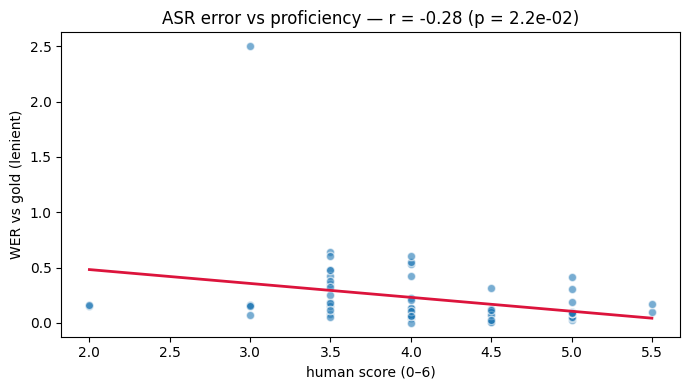

In [5]:
from scipy.stats import pearsonr

import matplotlib.pyplot as plt

r, p = pearsonr(wer.score, wer.wer_lenient)

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(wer.score, wer.wer_lenient, alpha=0.6, edgecolor="white")
m, b = np.polyfit(wer.score, wer.wer_lenient, 1)
xs = np.linspace(wer.score.min(), wer.score.max(), 2)
ax.plot(xs, m * xs + b, color="crimson", lw=2)
ax.set_xlabel("human score (0\u20136)")
ax.set_ylabel("WER vs gold (lenient)")
ax.set_title(f"ASR error vs proficiency \u2014 r = {r:+.2f} (p = {p:.1e})")
plt.tight_layout()

print(f"WER (lenient) vs score: r = {r:+.3f} (p = {p:.1e})")
print(f"WER (strict)  vs score: r = {pearsonr(wer.score, wer.wer_strict)[0]:+.3f}")

## 4. Filled-pause erasure, quantified

Notebook 01 inferred the erasure from Whisper's own output (`filled_pauses == 0` everywhere).
Now we can count what was *actually said*: the word-level annotations
(`dev-trans-ref.json`) mark `hesitation` tags (filled pauses) and `disfluency` words
(repetitions, false starts).

And the key question for the error-analysis report: **was the erased signal predictive?**

In [6]:
ann = json.load(open(REF / "annotations" / "dev-trans-ref.json"))
ann_map = {f["File-id"]: f["Transcript"] for f in ann["files"] if f["File-id"] in set(covered.utt)}

FILLED = re.compile(r"^(um+|uh+|er+m?|eh+|h?mm+)$", re.IGNORECASE)

rows = []
for utt, tr in ann_map.items():
    toks = [re.sub(r"[^a-z']", "", w["w"].lower()) for w in cache[utt]]
    rows.append({
        "utt": utt,
        "gold_hesitations": sum(1 for t in tr if t.get("tag") == "hesitation"),
        "gold_disfluencies": sum(1 for t in tr if "disfluency" in t.get("marks", [])),
        "n_gold_words": sum(1 for t in tr if "word" in t),
        "whisper_filled_pauses": sum(bool(FILLED.match(t)) for t in toks if t),
    })
fp = pd.DataFrame(rows).merge(covered[["utt", "score"]], on="utt")

g, w = fp.gold_hesitations.sum(), fp.whisper_filled_pauses.sum()
print(f"filled pauses actually spoken (gold hesitation tags): {g}")
print(f"filled pauses in Whisper output:                      {w}")
print(f"erasure rate: {1 - w / g:.1%}")
print(f"disfluency-marked words in gold: {fp.gold_disfluencies.sum()}")

# oracle: would the erased signal have helped a scorer?
fp["hes_rate"] = fp.gold_hesitations / fp.n_gold_words
fp["disfl_rate"] = fp.gold_disfluencies / fp.n_gold_words
for col in ["hes_rate", "disfl_rate"]:
    r, p = pearsonr(fp[col], fp.score)
    print(f"gold {col:10s} vs score: r = {r:+.3f} (p = {p:.3f})")

filled pauses actually spoken (gold hesitation tags): 333
filled pauses in Whisper output:                      0
erasure rate: 100.0%
disfluency-marked words in gold: 250
gold hes_rate   vs score: r = -0.210 (p = 0.094)
gold disfl_rate vs score: r = -0.249 (p = 0.046)


## 5. Prosody features from raw audio

These bypass ASR entirely — extracted straight from the FLAC with Praat (parselmouth):

| feature | what it captures |
|---|---|
| `f0_median_hz` | speaker's pitch register (control — speaker-dependent, not proficiency) |
| `f0_iqr_st` | pitch variability, in **semitones** (log-scale, so comparable across voices) |
| `f0_range_st` | 5th–95th percentile pitch span, semitones |
| `voiced_ratio` | fraction of frames with voicing — an acoustic phonation/fluency proxy |
| `intensity_sd_db` | loudness variability (caveat: recording gain varies by device, so means are untrustworthy; we use only the spread) |

Cached to `data/derived/` like the transcripts — delete the JSON to force re-extraction.

In [7]:
import parselmouth

PROSODY_FEATURES = ["f0_median_hz", "f0_iqr_st", "f0_range_st", "voiced_ratio", "intensity_sd_db"]

def prosody_features(path: Path) -> dict:
    snd = parselmouth.Sound(str(path))
    f0 = snd.to_pitch(time_step=0.01).selected_array["frequency"]   # 0 where unvoiced
    voiced = f0[f0 > 0]
    db = snd.to_intensity().values[0]
    db = db[np.isfinite(db) & (db > 0)]
    if len(voiced) < 10:                       # silent / no voicing detected
        return dict.fromkeys(PROSODY_FEATURES, 0.0)
    q05, q25, med, q75, q95 = np.percentile(voiced, [5, 25, 50, 75, 95])
    st = lambda hi, lo: 12 * np.log2(hi / lo)  # Hz ratio -> semitones
    return {
        "f0_median_hz": float(med),
        "f0_iqr_st": float(st(q75, q25)),
        "f0_range_st": float(st(q95, q05)),
        "voiced_ratio": float(len(voiced) / len(f0)),
        "intensity_sd_db": float(np.std(db)),
    }

PROSODY_CACHE = DERIVED / f"prosody_{PART}.json"
if PROSODY_CACHE.exists():
    prosody = json.load(open(PROSODY_CACHE))
else:
    prosody = {r.utt: prosody_features(CORPUS / r.flac) for r in sample.itertuples()}
    json.dump(prosody, open(PROSODY_CACHE, "w"))

pros = pd.DataFrame.from_dict(prosody, orient="index").rename_axis("utt").reset_index()
pros[PROSODY_FEATURES].describe().round(2).T[["mean", "std", "min", "max"]]   # aggregates only

,mean,std,min,max
f0_median_hz,167.39,44.47,88.64,258.20
f0_iqr_st,3.16,1.64,1.35,12.46
f0_range_st,10.10,4.34,3.87,26.99
voiced_ratio,0.49,0.11,0.00,0.67
intensity_sd_db,18.31,3.73,10.28,27.14


## 6. Fluency features, with MTLD replacing TTR

Same 11 features as notebook 01 (function duplicated verbatim for now — moves to `src/`
in the refactor step), plus **MTLD** (McCarthy & Jarvis 2010): mean factor length at a 0.72
TTR threshold, averaged over forward and backward passes. Unlike raw TTR it is
length-insensitive, which is exactly the artefact notebook 01 exposed.

In [8]:
import soundfile as sf

def fluency_features(words: list[dict], duration: float) -> dict:
    """Compute fluency features from Whisper word timestamps.

    words: [{'w': str, 's': start_sec, 'e': end_sec}, ...] in time order
    duration: audio file length in seconds
    """
    n = len(words)
    if n == 0:                       # silent / failed ASR -> all-zero row, flagged for exclusion
        return dict.fromkeys(
            ["duration_sec", "n_words", "speech_rate_wpm", "articulation_rate",
             "n_pauses", "total_pause_time", "mean_pause_dur", "n_long_pauses",
             "mean_length_of_run", "ttr", "filled_pauses"], 0.0) | {"duration_sec": duration}

    gaps = [w2["s"] - w1["e"] for w1, w2 in zip(words, words[1:])]
    pauses = [g for g in gaps if g >= PAUSE_GAP]
    phonation = sum(w["e"] - w["s"] for w in words)            # time spent actually speaking
    runs = np.split(np.arange(n), [i + 1 for i, g in enumerate(gaps) if g >= PAUSE_GAP])
    tokens = [re.sub(r"[^a-z']", "", w["w"].lower()) for w in words]
    tokens = [t for t in tokens if t]

    return {
        "duration_sec": duration,
        "n_words": n,
        "speech_rate_wpm": n / duration * 60,
        "articulation_rate": n / phonation * 60 if phonation > 0 else 0.0,
        "n_pauses": len(pauses),
        "total_pause_time": sum(pauses),
        "mean_pause_dur": float(np.mean(pauses)) if pauses else 0.0,
        "n_long_pauses": sum(g >= LONG_PAUSE for g in gaps),
        "mean_length_of_run": float(np.mean([len(r) for r in runs])),
        "ttr": len(set(tokens)) / len(tokens) if tokens else 0.0,
        "filled_pauses": sum(bool(FILLED.match(t)) for t in tokens),
    }

def mtld(tokens: list[str], threshold: float = 0.72) -> float:
    """Measure of Textual Lexical Diversity (McCarthy & Jarvis 2010)."""
    def one_pass(seq):
        factors, types, count = 0.0, set(), 0
        for t in seq:
            count += 1
            types.add(t)
            if len(types) / count <= threshold:
                factors += 1.0
                types, count = set(), 0
        if count:
            factors += (1 - len(types) / count) / (1 - threshold)
        return len(seq) / factors if factors else 0.0

    if len(tokens) < 10:
        return 0.0
    return (one_pass(tokens) + one_pass(tokens[::-1])) / 2

def tokens_of(words: list[dict]) -> list[str]:
    toks = [re.sub(r"[^a-z']", "", w["w"].lower()) for w in words]
    return [t for t in toks if t]

rows = []
for r in sample.itertuples():
    duration = sf.info(str(CORPUS / r.flac)).duration
    rows.append({"utt": r.utt, "score": r.score,
                 **fluency_features(cache[r.utt], duration),
                 "mtld": mtld(tokens_of(cache[r.utt]))})

feats = pd.DataFrame(rows)
empty = feats[feats.n_words == 0]
if len(empty):
    print(f"excluding {len(empty)} silent/failed-ASR responses (logged, per design doc)")
    feats = feats[feats.n_words > 0].reset_index(drop=True)

data = feats.merge(pros, on="utt")
print(f"feature matrix: {data.shape[0]} responses x {data.shape[1] - 2} features")

feature matrix: 100 responses x 17 features


## 7. Does prosody add signal? Model comparison

Identical protocol to notebook 01: Ridge (α=1.0), scaler inside the fold, 5-fold
`cross_val_predict`, QWK on the 0.5-step grid. Six feature sets, nested so each row
answers one question.

In [9]:
from sklearn.linear_model import Ridge
from sklearn.metrics import cohen_kappa_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr

FLUENCY_TTR = ["duration_sec", "n_words", "speech_rate_wpm", "articulation_rate",
               "n_pauses", "total_pause_time", "mean_pause_dur", "n_long_pauses",
               "mean_length_of_run", "ttr", "filled_pauses"]
FLUENCY_MTLD = [f if f != "ttr" else "mtld" for f in FLUENCY_TTR]

y = data.score.to_numpy()
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
pipe = lambda: make_pipeline(StandardScaler(), Ridge(alpha=1.0))

def to_grid(scores: np.ndarray) -> np.ndarray:
    """Snap to the human 0.5-step grid and code as integer classes (x2)."""
    snapped = np.clip(np.round(scores * 2) / 2, y.min(), y.max())
    return (snapped * 2).astype(int)

def evaluate(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    constant = np.ptp(y_pred) == 0                 # mean predictor: correlation undefined
                                                   # (ptp, not std: std of a constant array is ~1e-16, not 0)
    return {
        "pearson_r": np.nan if constant else pearsonr(y_true, y_pred)[0],
        "spearman_rho": np.nan if constant else spearmanr(y_true, y_pred)[0],
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "QWK": cohen_kappa_score(to_grid(y_true), to_grid(y_pred), weights="quadratic"),
    }

sets = {
    "mean predictor": None,
    "word-count Ridge": ["n_words"],
    "fluency Ridge (nb01, TTR)": FLUENCY_TTR,
    "fluency Ridge (MTLD)": FLUENCY_MTLD,
    "prosody-only Ridge": PROSODY_FEATURES,
    "fluency(MTLD) + prosody Ridge": FLUENCY_MTLD + PROSODY_FEATURES,
}
preds = {name: np.full_like(y, y.mean()) if cols is None
         else cross_val_predict(pipe(), data[cols].to_numpy(), y, cv=cv)
         for name, cols in sets.items()}

results = pd.DataFrame({name: evaluate(y, p) for name, p in preds.items()}).T
results.round(3)

,pearson_r,spearman_rho,MAE,RMSE,QWK
mean predictor,NaN,NaN,0.558,0.731,0.000
word-count Ridge,0.648,0.674,0.418,0.557,0.580
"fluency Ridge (nb01, TTR)",0.671,0.667,0.433,0.543,0.621
fluency Ridge (MTLD),0.660,0.676,0.431,0.550,0.647
prosody-only Ridge,0.331,0.391,0.550,0.694,0.210
fluency(MTLD) + prosody Ridge,0.651,0.691,0.446,0.559,0.644


In [10]:
# Which of the new features carry signal on their own? (aggregates only)
new_feats = ["ttr", "mtld"] + PROSODY_FEATURES
corr = pd.DataFrame(
    [{"feature": f,
      "pearson_r": pearsonr(data[f], y)[0],
      "p": pearsonr(data[f], y)[1]} for f in new_feats]
).set_index("feature").round(3)
corr

,pearson_r,p
feature,,
ttr,-0.230,0.021
mtld,0.337,0.001
f0_median_hz,0.097,0.335
f0_iqr_st,0.088,0.382
f0_range_st,0.034,0.737
voiced_ratio,0.232,0.020
intensity_sd_db,-0.342,0.000


## Findings

**ASR quality** (whisper-small, the 65 gold-covered responses)
- Corpus WER **16.8%** on content words; per-response mean 22.2% but median 12.1% — heavily right-skewed, a tail of responses is transcribed very badly.
- Scoring against the full disfluent reference adds **+4.1% WER** — the disfluency erasure cost in alignment terms.
- **WER rises as proficiency falls** (r = −0.28 lenient, −0.30 strict). ASR noise concentrates on exactly the speakers a scorer most needs to get right: feature quality is systematically worse for weaker candidates. This goes straight into the fairness analysis.

**Disfluency erasure, now against ground truth**
- 333 filled pauses were actually spoken (gold `hesitation` tags); Whisper output contains **0** — the 100% erasure from notebook 01 confirmed against annotation, not inferred from the model's own silence.
- The erased signal is predictive: gold disfluency rate correlates with score at r = −0.25 (p = .046), hesitation rate r = −0.21. A Whisper-fed scorer is blind to a real proficiency cue.

**MTLD fixes the TTR artefact**
- TTR: r = −0.23 (the length artefact). MTLD: r = **+0.34**, the right sign and the strongest legitimate new correlate.
- Swapping TTR → MTLD lifts the fluency Ridge from QWK 0.621 to **0.647** — best model so far. (The TTR row reproduces notebook 01 exactly: same sample, same folds.)

**Prosody adds nothing — yet**
- Prosody-only Ridge: QWK 0.21. Weak but above chance, so the features are not dead.
- Added to fluency(MTLD): QWK 0.644 vs 0.647 — no gain. With n=100 and a linear model, the voicing signal (`voiced_ratio`, r = +0.23) is largely already carried by the pause features.
- `intensity_sd_db` (r = −0.34) is the strongest single prosody correlate but suspect: loudness variability plausibly tracks recording conditions, not proficiency. Flag it for the audio-quality fairness slice rather than trusting it as a scoring feature.

**Next (roadmap step 5–6):** refactor `fluency_features`/`mtld`/`evaluate` into `src/` with pytest fixtures, scale to the full dev set (3,249 responses — where prosody and the WER–score relationship get a real sample size), then text features and non-linear models.